In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from dotenv import load_dotenv
import pickle

from torchvision import transforms
from torchvision.datasets import ImageFolder

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from PIL import Image

In [26]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

In [27]:
import warnings
warnings.filterwarnings('ignore')

**TO ACCESS DATA IN COLLAB**

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset/

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset/versions/
License(s): copyright-authors
100% 2.70G/2.70G [02:34<00:00, 18.7MB/s]



In [ ]:
import zipfile
with zipfile.ZipFile('new-plant-diseases-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [ ]:
TRAIN_DIR = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
VALID_DIR = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'
TEST_DIR = '/content/test/test'

**PRE INFO**

In [ ]:
load_dotenv()

TRAIN_DIR = os.getenv("train_folder")
TEST_DIR = os.getenv("test_folder")
VALID_DIR = os.getenv("valid_folder")

**TRANSFORMS and DATASET, DATALOADER**

In [28]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

**TRAIN AND VAL BLOCKS**

In [33]:
def train_block(model, train_dataloader, criterion, optimizer, device):
  model.to(device)
  model.train()

  total_batch_loss = 0.0
  correctly_predicted = 0
  total = 0

  for images, labels in train_dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    total_batch_loss += loss.item()
    total += len(labels)
    _,predicted = torch.max(output, 1)
    correctly_predicted += (predicted == labels).sum().item()

  epoch_loss = total_batch_loss/len(train_dataloader)
  acc = correctly_predicted/total

  return epoch_loss, acc

In [ ]:
def val_block(model, valid_dataloader, criterion, device):
  model.to(device)
  model.eval()

  total_batch_loss = 0.0
  correctly_predicted = 0
  total = 0

  with torch.no_grad():

    for images, labels in valid_dataloader:
      images = images.to(device)
      labels = labels.to(device)


      output = model(images)
      loss = criterion(output, labels)

      total_batch_loss += loss.item()
      total += len(labels)
      _,predicted = torch.max(output, 1)
      correctly_predicted += (predicted == labels).sum().item()

    epoch_loss = total_batch_loss/len(valid_dataloader)
    acc = correctly_predicted/total

  return epoch_loss, acc

**PRE TRAINED MODELS**

In [ ]:
from torchvision import models

In [40]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

**RESNET50**

In [74]:
resnet_weights = models.ResNet50_Weights.DEFAULT
resnet = models.resnet50(weights=resnet_weights)

In [79]:
for param in resnet.parameters():
    param.requires_grad = False

In [80]:
num_features = resnet.fc.in_features

In [81]:
resnet.fc = nn.Sequential(
            nn.Linear(num_features,num_classes)
)

In [75]:
train_transforms = resnet_weights.transforms()
valid_transforms = resnet_weights.transforms()

In [76]:
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transforms)
valid_dataset = ImageFolder(VALID_DIR, transform=valid_transforms)

In [77]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [78]:
class_names = train_dataset.classes
num_classes = len(class_names)
num_classes

38

In [82]:
learning_rate = 0.05
epochs = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet.parameters(), lr=learning_rate)

In [83]:
train_losses_resnet = []
valid_losses_resnet = []

train_accs_resnet = []
valid_accs_resnet = []

In [84]:
for epoch in range(epochs):

  train_loss, train_acc = train_block(resnet, train_dataloader, criterion, optimizer, device)
  valid_loss, valid_acc = val_block(resnet, valid_dataloader, criterion, device)

  train_losses_resnet.append(train_loss)
  train_accs_resnet.append(train_acc)

  valid_losses_resnet.append(valid_loss)
  valid_accs_resnet.append(valid_acc)

  print(f'epoch {epoch+1} train_loss {train_loss} train_acc {train_acc} valid_loss {valid_loss} valid_acc {valid_acc}')

epoch 1 train_loss 1.469682448298753 train_acc 0.8735898712568462 valid_loss 1.0323742850340925 valid_acc 0.9321648076485317
epoch 2 train_loss 1.1247473113460777 train_acc 0.935486165445622 valid_loss 1.290871885953784 valid_acc 0.9408149328477122
epoch 3 train_loss 0.9913198345404665 train_acc 0.9510349242478128 valid_loss 1.040090972373706 valid_acc 0.9557250170726155
epoch 4 train_loss 0.9552562330179047 train_acc 0.9574649690589658 valid_loss 1.2495562894938006 valid_acc 0.9521397678124288
epoch 5 train_loss 0.845275443330132 train_acc 0.9638096592929796 valid_loss 1.1425027894495072 valid_acc 0.9607329842931938
epoch 6 train_loss 0.8480132526494553 train_acc 0.966384522370012 valid_loss 1.0280622563761843 valid_acc 0.9650011381743683
epoch 7 train_loss 0.8047905832644296 train_acc 0.9702112525784196 valid_loss 0.8330378256095111 valid_acc 0.972626906442067
epoch 8 train_loss 0.7300956915697805 train_acc 0.9725727292126041 valid_loss 1.0570411468109424 valid_acc 0.9675051217846574

In [85]:
torch.save(resnet.state_dict(),'resnet.pkl')

In [86]:
with open('train_losses_resnetet.pkl','wb') as f:
  pickle.dump(train_losses_resnet, f)

with open('valid_losses_resnet.pkl','wb') as f:
  pickle.dump(valid_losses_resnet, f)

with open('train_accs_resnet.pkl','wb') as f:
  pickle.dump(train_accs_resnet, f)

with open('valid_accs_resnet.pkl','wb') as f:
  pickle.dump(valid_accs_resnet, f)

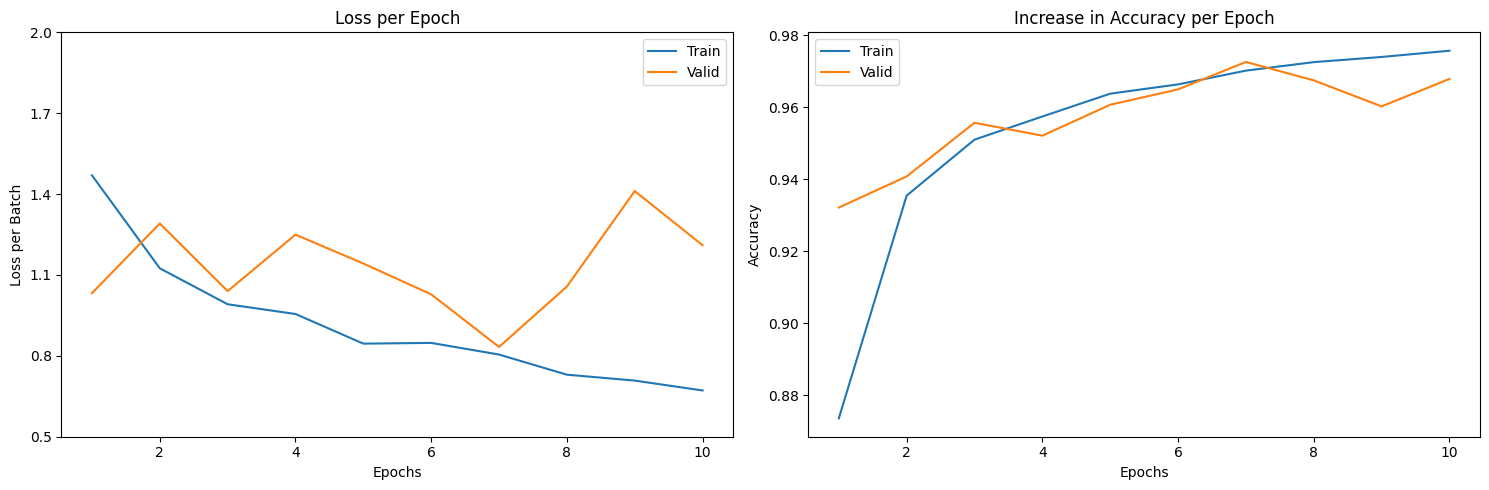

In [89]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(range(1,11),train_losses_resnet, label='Train')
plt.plot(range(1,11),valid_losses_resnet, label='Valid')
plt.title('Loss per Epoch')
plt.yticks(np.arange(0.5,2.1,0.3))
plt.xlabel('Epochs')
plt.ylabel('Loss per Batch')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1,11),train_accs_resnet, label='Train')
plt.plot(range(1,11),valid_accs_resnet, label='Valid')
plt.title('Increase in Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()